### Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, roc_curve, confusion_matrix, classification_report, accuracy_score)

### Data Exploration

In [2]:
#Loading data
df = pd.read_csv("hospital_readmissions_30k.csv")
df.head()

,patient_id,age,gender,blood_pressure,cholesterol,bmi,diabetes,hypertension,medication_count,length_of_stay,discharge_destination,readmitted_30_days
0,1,74,Other,130/72,240,31.5,Yes,No,5,1,Nursing_Facility,Yes
1,2,46,Female,120/92,292,36.3,No,No,4,3,Nursing_Facility,No
2,3,89,Other,135/78,153,30.3,No,Yes,1,1,Home,No
3,4,84,Female,123/80,153,31.5,No,Yes,3,10,Home,No
4,5,32,Other,135/84,205,18.4,No,Yes,6,4,Nursing_Facility,No


In [3]:
#Rows and Columns
print(f"Shape: {df.shape}")
print(f"Columns: {np.array(df.columns)}")

Shape: (30000, 12)
Columns: ['patient_id' 'age' 'gender' 'blood_pressure' 'cholesterol' 'bmi'
 'diabetes' 'hypertension' 'medication_count' 'length_of_stay'
 'discharge_destination' 'readmitted_30_days']


In [4]:
#Basic info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   patient_id             30000 non-null  int64  
 1   age                    30000 non-null  int64  
 2   gender                 30000 non-null  str    
 3   blood_pressure         30000 non-null  str    
 4   cholesterol            30000 non-null  int64  
 5   bmi                    30000 non-null  float64
 6   diabetes               30000 non-null  str    
 7   hypertension           30000 non-null  str    
 8   medication_count       30000 non-null  int64  
 9   length_of_stay         30000 non-null  int64  
 10  discharge_destination  30000 non-null  str    
 11  readmitted_30_days     30000 non-null  str    
dtypes: float64(1), int64(5), str(6)
memory usage: 2.7 MB


In [5]:
#Nulls and Duplicates
print(f"Null Values:\n{df.isnull().sum()}")
print(f"Duplicates: {df.duplicated().sum()}")

Null Values:
patient_id               0
age                      0
gender                   0
blood_pressure           0
cholesterol              0
bmi                      0
diabetes                 0
hypertension             0
medication_count         0
length_of_stay           0
discharge_destination    0
readmitted_30_days       0
dtype: int64
Duplicates: 0


In [6]:
#Statical View
df.describe()

,patient_id,age,cholesterol,bmi,medication_count,length_of_stay
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,53.884233,225.260400,28.946263,5.012267,5.502900
std,8660.398374,21.056485,43.585671,6.348204,3.166383,2.867298
min,1.000000,18.000000,150.000000,18.000000,0.000000,1.000000
25%,7500.750000,36.000000,188.000000,23.400000,2.000000,3.000000
50%,15000.500000,54.000000,225.000000,28.900000,5.000000,5.000000
75%,22500.250000,72.000000,263.000000,34.500000,8.000000,8.000000
max,30000.000000,90.000000,300.000000,40.000000,10.000000,10.000000


### Train-Test Split

In [7]:
X = df.drop("readmitted_30_days", axis=1)
y = df["readmitted_30_days"].map({"No": 0, "Yes": 1})
print("Target Values:")
print(y.value_counts())

Target Values:
readmitted_30_days
0    26326
1     3674
Name: count, dtype: int64


In [8]:
#Applying One Hot Encoding
X = pd.get_dummies(X, drop_first=True)
X.head()

,patient_id,age,cholesterol,bmi,medication_count,length_of_stay,gender_Male,gender_Other,blood_pressure_110/70,blood_pressure_110/71,...,blood_pressure_160/94,blood_pressure_160/95,blood_pressure_160/96,blood_pressure_160/97,blood_pressure_160/98,blood_pressure_160/99,diabetes_Yes,hypertension_Yes,discharge_destination_Nursing_Facility,discharge_destination_Rehab
0,1,74,240,31.5,5,1,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False
1,2,46,292,36.3,4,3,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,3,89,153,30.3,1,1,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
3,4,84,153,31.5,3,10,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
4,5,32,205,18.4,6,4,False,True,False,False,...,False,False,False,False,False,False,False,True,True,False


In [9]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (24000, 1592)
Testing Data: (6000, 1592)


In [10]:
#Scaling Between 0-1
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Model Training

In [11]:
model = LogisticRegression(penalty="l2", C=1.0, max_iter=1000, random_state=42)
model.fit(X_train, y_train)

C:\Users\shaur\miniconda3\envs\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'l2'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To 

In [12]:
y_pred = model.predict(X_test)
print(f"Predicted Classes: {y_pred[:10]}")

#Probability of readmission
y_prob = model.predict_proba(X_test)[:, 1]
print(f"Readmission Probabilities: {y_prob[:10]}")

Predicted Classes: [0 0 0 0 0 0 0 0 0 0]
Readmission Probabilities: [0.1503586  0.13753142 0.39872524 0.05492992 0.06912364 0.06619643
 0.23489175 0.05296674 0.21092308 0.1708213 ]


### Metrics

In [13]:
print(f"Accuracy Score: {accuracy_score(y_test, y_pred)}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob)}")

Accuracy Score: 0.8706666666666667
ROC-AUC Score: 0.5202075055703482


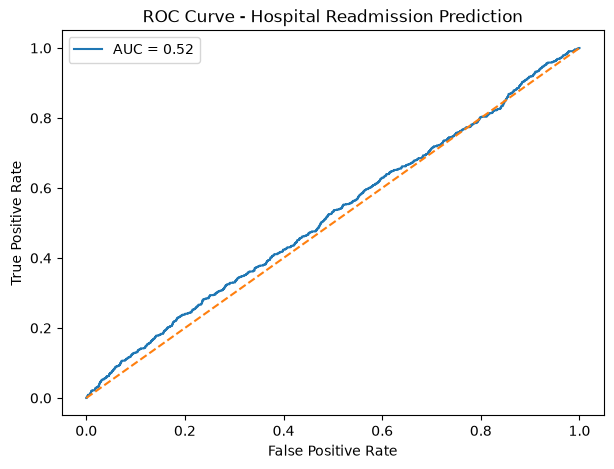

In [15]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Hospital Readmission Prediction")
plt.legend()

plt.show()

In [16]:
print(f"Confusion Matirx:\n{confusion_matrix(y_test, y_pred)}")

Confusion Matirx:
[[5222    9]
 [ 767    2]]


In [17]:
print(f"Classification_report:\n{classification_report(y_test, y_pred)}")

Classification_report:
              precision    recall  f1-score   support

           0       0.87      1.00      0.93      5231
           1       0.18      0.00      0.01       769

    accuracy                           0.87      6000
   macro avg       0.53      0.50      0.47      6000
weighted avg       0.78      0.87      0.81      6000



In [18]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives: {tp}")
print(f"True Negatives: {tn}")

False Positives: 9
False Negatives: 767
True Positives: 2
True Negatives: 5222
